In [13]:
import numpy as np
from MC2PCA import MC2PCA
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from tqdm import tqdm
from sktime.datasets import load_japanese_vowels
from sklearn.metrics import confusion_matrix
from scipy.optimize import linear_sum_assignment
np.random.seed(0)

In [2]:
X_train, y_train = load_japanese_vowels(return_X_y=True, split="train")

In [3]:
def sktime_to_matrices(X):
    series_list = []
    for i in range(len(X)):
        cols = [X.iloc[i, j] for j in range(X.shape[1])]
        Xi = np.column_stack(cols)
        series_list.append(Xi)
    return series_list


In [4]:
series_list = sktime_to_matrices(X_train)


In [5]:
model = MC2PCA(p=3, tol=1e-7, max_iter=50)
model.fit(series_list, K=9)


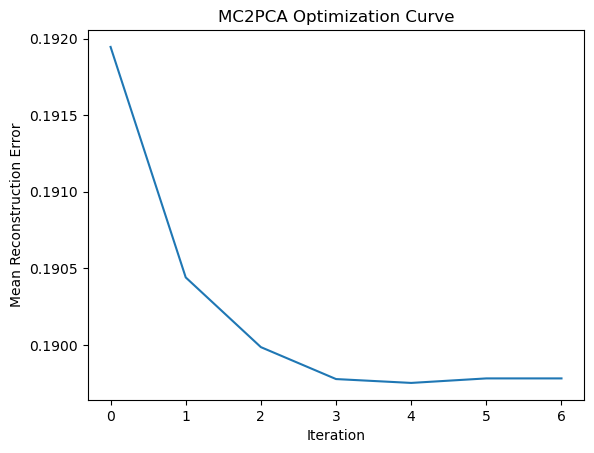

In [6]:
plt.plot(model.errors)
plt.title("MC2PCA Optimization Curve")
plt.xlabel("Iteration")
plt.ylabel("Mean Reconstruction Error")
plt.show()


In [7]:
print(series_list[0].shape)
print(len(series_list))


(20, 12)
270


#### Use different data shuffling and see results => evaluate robustness of initialisation


In [8]:
def run_mc2pca_with_shuffle(series_list, K, p, seed):
    rng = np.random.default_rng(seed)
    idx = rng.permutation(len(series_list))
    
    series_shuffled = [series_list[i] for i in idx]

    model = MC2PCA(p=p, tol=1e-7, max_iter=50)
    model.fit(series_shuffled, K)

    return {
        "errors": model.errors,
        "final_error": model.errors[-1],
        "cluster_sizes": [len(c) for c in model.clusters]
    }


In [9]:
n_runs = 10
results = []

for seed in range(n_runs):
    res = run_mc2pca_with_shuffle(
        series_list=series_list,
        K=9,
        p=3,
        seed=seed
    )
    results.append(res)


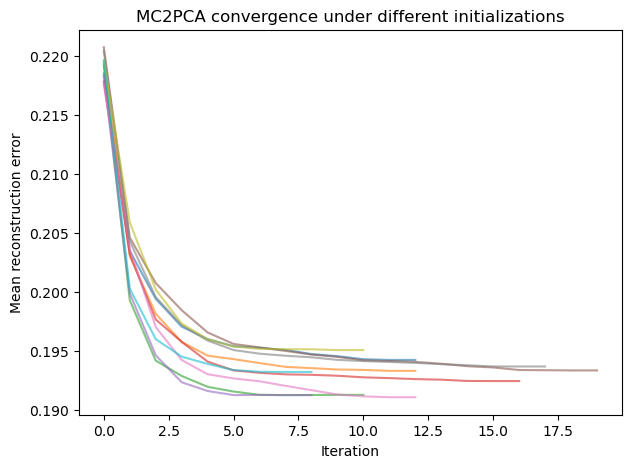

In [10]:
plt.figure(figsize=(7,5))

for r in results:
    plt.plot(r["errors"], alpha=0.6)

plt.title("MC2PCA convergence under different initializations")
plt.xlabel("Iteration")
plt.ylabel("Mean reconstruction error")
plt.show()


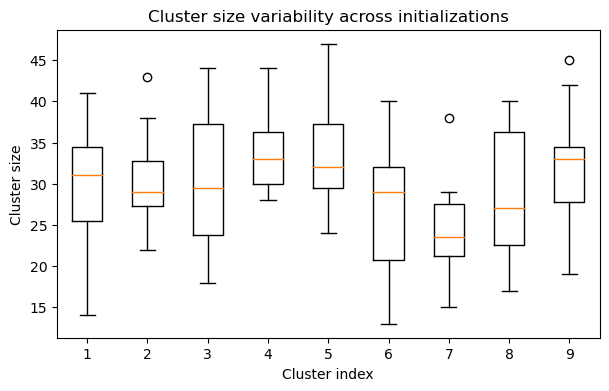

In [11]:
cluster_sizes = np.array([r["cluster_sizes"] for r in results])

plt.figure(figsize=(7,4))
plt.boxplot(cluster_sizes, positions=range(1,10))
plt.xlabel("Cluster index")
plt.ylabel("Cluster size")
plt.title("Cluster size variability across initializations")
plt.show()


#### Evaluate number of components (pca) vs. precision


In [18]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)


In [19]:
def clustering_accuracy(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    row_ind, col_ind = linear_sum_assignment(-cm)
    return cm[row_ind, col_ind].sum() / cm.sum()


In [21]:
ps = [1, 2, 3, 4, 5, 6, 8, 10]
accuracies = []

for p in ps:
    model = MC2PCA(p=p, tol=1e-7, max_iter=50)
    model.fit(series_list, K=9)

    acc = clustering_accuracy(y_train_enc, model.assignments)
    accuracies.append(acc)

    print(f"p = {p} | accuracy = {acc:.3f}")


p = 1 | accuracy = 0.652
p = 2 | accuracy = 0.752
p = 3 | accuracy = 0.730
p = 4 | accuracy = 0.726
p = 5 | accuracy = 0.763
p = 6 | accuracy = 0.781
p = 8 | accuracy = 0.733
p = 10 | accuracy = 0.548


#### Evaluate precision vs. number of missing data


In [23]:
def add_missing_data(X, missing_rate, seed=0):
    rng = np.random.default_rng(seed)
    X_corrupted = X.copy()

    mask = rng.random(X_corrupted.shape) < missing_rate
    X_corrupted[mask] = 0.0

    return X_corrupted


In [27]:
missing_rates = [0.0, 0.05, 0.2, .4, 0.5, 0.6, 0.95, 0.99]
accuracies = []

for mr in missing_rates:
    corrupted_series = [
        add_missing_data(Xi, mr, seed=0) for Xi in series_list
    ]

    model = MC2PCA(p=6, tol=1e-7, max_iter=50)
    model.fit(corrupted_series, K=9)

    acc = clustering_accuracy(y_train_enc, model.assignments)
    accuracies.append(acc)

    print(f"Missing rate = {mr:.2f} | accuracy = {acc:.3f}")


Missing rate = 0.00 | accuracy = 0.781
Missing rate = 0.05 | accuracy = 0.819
Missing rate = 0.20 | accuracy = 0.793
Missing rate = 0.40 | accuracy = 0.778
Missing rate = 0.50 | accuracy = 0.781
Missing rate = 0.60 | accuracy = 0.752
Missing rate = 0.95 | accuracy = 0.381
Missing rate = 0.99 | accuracy = 0.181
